<a href="https://colab.research.google.com/github/Yam3012/m13-ml-forecast-olist/blob/main/notebooks/Sprint1/sprint1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Vision Flow**

**integrantes**

*   Yamil Gamarra Lopez
*   Marianela Loza Rios
*   Enrique Yupanqui






In [1]:
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

orders   = pd.read_csv('/content/drive/MyDrive/olist_orders_dataset.csv',
                       parse_dates=['order_purchase_timestamp',
                                    'order_approved_at',
                                    'order_delivered_carrier_date',
                                    'order_delivered_customer_date',
                                    'order_estimated_delivery_date']) # use parse_date porque como haremos un analisis temporal mensual y necesitamos
                                                                      # que no lo lea como objeto sino q respete datetime
                                                                      # para calcular tiempos de entrega, agrupar por mes y analizar la demanda por tiempo.

items    = pd.read_csv('/content/drive/MyDrive/olist_order_items_dataset.csv')
products = pd.read_csv('/content/drive/MyDrive/olist_products_dataset.csv')
reviews  = pd.read_csv('/content/drive/MyDrive/olist_order_reviews_dataset.csv')
payments = pd.read_csv('/content/drive/MyDrive/olist_order_payments_dataset.csv')


Mounted at /content/drive


In [3]:
print("Orders:", orders.shape) # Fechas, estado, tiempos de entrega
print("Items:", items.shape) # Productos vendidos, precios
print("Products:", products.shape)# Categorías de producto
print("Reviews:", reviews.shape) # Calificaciones de clientes
print("Payments:", payments.shape) # Tipos de pago, montos

orders.head(2)


Orders: (99441, 8)
Items: (112650, 7)
Products: (32951, 9)
Reviews: (99224, 7)
Payments: (103886, 5)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13


`order_id`(ID del pedido): identificador para unir con otras tablas (items, payments, reviews).

`customer_id`(Cliente que hizo el pedido): Sirve si más adelante analizas demanda por cliente o región.             

`order_purchase_timestamp`(Fecha y hora de compra): Marca temporal principal (para agrupar por mes).                           

`order_delivered_customer_date`(Fecha en que el pedido fue entregado): Para calcular los días de entrega.                                         

`order_status`(Estado delivered, shipped, canceled, etc.): Sirve para filtrar solo los pedidos entregados.

In [6]:
# columnas elegidad
orders_min = orders[['order_id', 'customer_id', 'order_purchase_timestamp',
                     'order_delivered_customer_date', 'order_status']].copy()

# Filtramos pedidos entregados para evitar cancelados
orders_min = orders_min[orders_min['order_status']=='delivered'].copy()

# feature Mes de compra variable temporal mensual
orders_min['order_month'] = orders_min['order_purchase_timestamp'].dt.to_period('M').astype(str)

# Tiempo de entrega pr ejemplo: 2017-11-23 - 2017-11-28 = 5
orders_min['delivery_time_days'] = (
    orders_min['order_delivered_customer_date'] - orders_min['order_purchase_timestamp']
).dt.days

print(orders_min.shape)
orders_min.head(3)


(96478, 7)


,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date,order_status,order_month,delivery_time_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-10 21:25:13,delivered,2017-10,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-08-07 15:27:45,delivered,2018-07,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-17 18:06:29,delivered,2018-08,9.0


In [9]:
# Items + Products - para conocer la categoría
#Cuántos productos de cada categoría se vendieron por pedido.
#Cuánto costaban (price) y cuánto se pagó de envío (freight_value).

items_min = items[['order_id','product_id','price','freight_value']].copy()
prods_min = products[['product_id','product_category_name']].copy()

# Une cada ítem con su categoría
items_prod = items_min.merge(prods_min, on='product_id', how='left')

items_prod['product_category_name'].isna().mean()
items_prod.head(3)

,order_id,product_id,price,freight_value,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,58.9,13.29,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,239.9,19.93,pet_shop
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,199.0,17.87,moveis_decoracao


In [10]:
# Sumar por order_id y tipo de pago
pay_sum = (payments
.groupby(['order_id','payment_type'], as_index=False)['payment_value']
.sum())


pay_pivot = pay_sum.pivot(index='order_id', columns='payment_type', values='payment_value').fillna(0.0)
pay_pivot.columns = [f'pay_{c}' for c in pay_pivot.columns]
pay_pivot = pay_pivot.reset_index()


# Total y ratio por tarjeta / boleto a nivel pedido
for col in ['pay_credit_card','pay_boleto']:
  if col not in pay_pivot.columns:
    pay_pivot[col] = 0.0


pay_pivot['pay_total'] = pay_pivot.filter(like='pay_').sum(axis=1)
pay_pivot['payment_credit_ratio_order'] = np.where(pay_pivot['pay_total']>0,
pay_pivot['pay_credit_card']/pay_pivot['pay_total'], 0.0)
pay_pivot['payment_boleto_ratio_order'] = np.where(pay_pivot['pay_total']>0,
pay_pivot['pay_boleto']/pay_pivot['pay_total'], 0.0)

pay_pivot[['order_id','payment_credit_ratio_order']].head(5)


,order_id,payment_credit_ratio_order
0,00010242fe8c5a6d1ba2dd792cb16214,1.0
1,00018f77f2f0320c557190d7a144bdd3,1.0
2,000229ec398224ef6ca0657da4fc703e,1.0
3,00024acbcdf0a6daa1e931b038114c75,1.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1.0


In [11]:
# Promediamos si hay múltiples reseñas por order_id
rev_min = (reviews[['order_id','review_score']]
           .groupby('order_id', as_index=False)['review_score']
           .mean()
           .rename(columns={'review_score':'review_score_order'}))

rev_min.head(5)


,order_id,review_score_order
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


In [14]:
df = (items_prod
  .merge(orders_min, on='order_id', how='left')
  .merge(pay_pivot[['order_id','payment_credit_ratio_order','payment_boleto_ratio_order']], on='order_id', how='left')
  .merge(rev_min, on='order_id', how='left'))


# Limpiezas mínimas
for c in ['payment_credit_ratio_order','payment_boleto_ratio_order']:
  df[c] = df[c].fillna(0.0)


# Mantener filas válidas
df = df[df['order_month'].notna() & df['product_category_name'].notna()].copy()
print('df:', df.shape)

print(df.shape)
df.head(3)


df: (108660, 14)
(108660, 14)


,order_id,product_id,price,freight_value,product_category_name,customer_id,order_purchase_timestamp,order_delivered_customer_date,order_status,order_month,delivery_time_days,payment_credit_ratio_order,payment_boleto_ratio_order,review_score_order
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,58.9,13.29,cool_stuff,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,2017-09-20 23:43:48,delivered,2017-09,7.0,1.0,0.0,5.0
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,239.9,19.93,pet_shop,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,2017-05-12 16:04:24,delivered,2017-04,16.0,1.0,0.0,4.0
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,199.0,17.87,moveis_decoracao,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,2018-01-22 13:19:16,delivered,2018-01,7.0,1.0,0.0,5.0


In [15]:
# Agregamos por (mes, categoría)
agg = (df.groupby(['order_month','product_category_name'], as_index=False)
  .agg(
    demand=('product_id','count'),
    total_sales=('price','sum'),
    avg_price=('price','mean'),
    avg_freight=('freight_value','mean'),
    avg_review_score=('review_score_order','mean'),
    avg_delivery_time_days=('delivery_time_days','mean'),
    payment_credit_ratio=('payment_credit_ratio_order','mean'),
    payment_boleto_ratio=('payment_boleto_ratio_order','mean')
    ))

# Orden cronológico
agg = agg.sort_values(['product_category_name','order_month']).reset_index(drop=True)
agg.head(10)


,order_month,product_category_name,demand,total_sales,avg_price,avg_freight,avg_review_score,avg_delivery_time_days,payment_credit_ratio,payment_boleto_ratio
0,2017-01,agro_industria_e_comercio,3,65.97,21.990000,13.930000,4.333333,8.000000,1.000000,0.000000
1,2017-02,agro_industria_e_comercio,7,224.84,32.120000,15.180000,3.857143,12.571429,0.641116,0.285714
2,2017-03,agro_industria_e_comercio,2,81.99,40.995000,14.350000,2.000000,8.500000,0.500000,0.000000
3,2017-05,agro_industria_e_comercio,4,1579.94,394.985000,45.950000,4.750000,11.250000,0.750000,0.250000
4,2017-06,agro_industria_e_comercio,1,1390.00,1390.000000,32.050000,1.000000,9.000000,1.000000,0.000000
5,2017-07,agro_industria_e_comercio,1,1180.00,1180.000000,19.470000,5.000000,4.000000,1.000000,0.000000
6,2017-08,agro_industria_e_comercio,4,88.00,22.000000,34.150000,5.000000,18.000000,1.000000,0.000000
7,2017-09,agro_industria_e_comercio,4,1993.99,498.497500,31.425000,3.250000,10.000000,1.000000,0.000000
8,2017-10,agro_industria_e_comercio,5,3350.28,670.056000,41.630000,4.200000,10.200000,0.600000,0.400000
9,2017-11,agro_industria_e_comercio,19,13932.49,733.288947,35.675263,2.789474,18.052632,0.421053,0.578947


In [16]:
p = pd.PeriodIndex(agg['order_month'], freq='M')
agg['year'] = p.year
agg['month_num'] = p.month


# Dummies de meses clave en Brasil
agg['is_november'] = (agg['month_num'] == 11).astype(int)
agg['is_may'] = (agg['month_num'] == 5).astype(int)
agg['is_august'] = (agg['month_num'] == 8).astype(int)
agg['is_december'] = (agg['month_num'] == 12).astype(int)
agg['is_june'] = (agg['month_num'] == 6).astype(int)
agg['is_october'] = (agg['month_num'] == 10).astype(int)


# Variables cíclicas
agg['month_sin'] = np.sin(2*np.pi*agg['month_num']/12)
agg['month_cos'] = np.cos(2*np.pi*agg['month_num']/12)


# Proxy de costo percibido
agg['freight_ratio'] = agg['avg_freight'] / agg['avg_price']
agg['freight_ratio'] = agg['freight_ratio'].replace([np.inf, -np.inf], np.nan).fillna(0)

In [36]:
# Tabla de % por mes-categoría a partir de reviews a nivel pedido
rev_order = (df[['order_month','product_category_name','review_score_order']]
              .dropna())


rev_month = (rev_order
              .assign(is_5=lambda x: (x['review_score_order']==5).astype(int),
              is_neg=lambda x: (x['review_score_order']<=2).astype(int))
              .groupby(['order_month','product_category_name'], as_index=False)
              .agg(
              pct_5_star=('is_5','mean'),
              pct_negative=('is_neg','mean')
              ))


# Desplazar +1 mes para alinear como feature de t que impacta demanda de t+1
rev_p = pd.PeriodIndex(rev_month['order_month'], freq='M') + 1
rev_month_shift = rev_month.copy()
rev_month_shift['order_month'] = rev_p.astype(str)


# Unimos a agg (mismas claves logica mia)
agg = agg.merge(rev_month_shift, on=['order_month','product_category_name'], how='left')

In [37]:
agg = agg.sort_values(['product_category_name','order_month']).reset_index(drop=True)
def add_targets_and_lags(g):
    g = g.sort_values('order_month').copy()
    # Target t+1
    g['demand_next_month'] = g['demand'].shift(-1)
    # Lags clásicos
    g['demand_last_month'] = g['demand'].shift(1)
    g['demand_last_year'] = g['demand'].shift(12)
    # Medias móviles con shift(1) para evitar fuga de información
    g['ma_3'] = g['demand'].rolling(3).mean().shift(1)
    g['ma_6'] = g['demand'].rolling(6).mean().shift(1)
    return g

master = agg.groupby('product_category_name', group_keys=False).apply(add_targets_and_lags)

# Quitamos filas sin target (último mes por categoría)
master = master.dropna(subset=['demand_next_month']).reset_index(drop=True)
print('master:', master.shape)

master: (1179, 32)


/tmp/ipython-input-846148760.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  master = agg.groupby('product_category_name', group_keys=False).apply(add_targets_and_lags)


**TARGET**

demand_next_month

**Tendencia / rezagos**

demand_last_month

demand_last_year

ma_3

ma_6

**Logística / comportamiento**

avg_delivery_time_days

payment_credit_ratio

payment_boleto_ratio

**Satisfacción del cliente**

avg_review_score

pct_5_star

pct_negative

**Precio / costos**

avg_price

avg_freight

freight_ratio

**Estacionalidad**

year

month_num

is_november, is_may, is_august, is_december, is_june, is_october

month_sin, month_cos

In [38]:
master[['demand', 'demand_next_month',
        'demand_last_month', 'demand_last_year']].describe()

master[['demand', 'demand_next_month']].isna().sum()

(master[['demand', 'demand_next_month',
         'demand_last_month', 'demand_last_year']] < 0).sum()


,0
demand,0
demand_next_month,0
demand_last_month,0
demand_last_year,0


In [39]:
master[['ma_3', 'ma_6']].describe()

master[['ma_3', 'ma_6']].isna().sum()

(master[['ma_3', 'ma_6']] < 0).sum()


,0
ma_3,0
ma_6,0


In [40]:
master['avg_delivery_time_days'].describe()

master['avg_delivery_time_days'].isna().sum()

(master['avg_delivery_time_days'] < 0).sum()


np.int64(0)

In [41]:
master[['payment_credit_ratio', 'payment_boleto_ratio']].describe()

(master[['payment_credit_ratio', 'payment_boleto_ratio']] < 0).sum()
(master[['payment_credit_ratio', 'payment_boleto_ratio']] > 1).sum()

master[['payment_credit_ratio', 'payment_boleto_ratio']].isna().sum()


,0
payment_credit_ratio,0
payment_boleto_ratio,0


In [42]:
master[['avg_review_score','pct_5_star','pct_negative']].describe()

(master[['pct_5_star','pct_negative']] < 0).sum()
(master[['pct_5_star','pct_negative']] > 1).sum()

master[['avg_review_score','pct_5_star','pct_negative']].isna().sum()


,0
avg_review_score,2
pct_5_star,151
pct_negative,151


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Para baseline, usamos la serie 'demand' vs. predicciones de naive_last_year y ma3 "simulados" con columnas ya creadas
tmp = master.dropna(subset=['demand_last_year','ma_3']).copy()

def mape(y, yhat):
    y, yhat = np.array(y), np.array(yhat)
    mask = y != 0
    return (np.abs((yhat[mask]-y[mask]) / y[mask])).mean()*100

res = []
for col in ['demand_last_year','ma_3']:
    # To calculate RMSE, we take the square root of the MSE returned by mean_squared_error.
    # The 'squared' parameter was introduced in scikit-learn 0.22.
    rmse = np.sqrt(mean_squared_error(tmp['demand'], tmp[col]))
    mae  = mean_absolute_error(tmp['demand'], tmp[col])
    mp   = mape(tmp['demand'], tmp[col])
    res.append((col, rmse, mae, mp))

baseline_scores = pd.DataFrame(res, columns=['baseline','RMSE','MAE','MAPE']).sort_values('MAPE')
baseline_scores

,baseline,RMSE,MAE,MAPE
1,ma_3,65.641904,34.564312,39.403247
0,demand_last_year,184.005745,105.326087,73.374671


In [21]:
base_path = '/content/drive/MyDrive/'
out_path = base_path + 'olist_master_forecast.csv'
master.to_csv(out_path, index=False, encoding='utf-8')
out_path


'/content/drive/MyDrive/olist_master_forecast.csv'

In [35]:
master.head(3)

,order_month,product_category_name,demand,total_sales,avg_price,avg_freight,avg_review_score,avg_delivery_time_days,payment_credit_ratio,payment_boleto_ratio,...,freight_ratio,pct_5_star_x,pct_negative_x,pct_5_star_y,pct_negative_y,demand_next_month,demand_last_month,demand_last_year,ma_3,ma_6
0,2017-01,agro_industria_e_comercio,3,65.97,21.990,13.93,4.333333,8.000000,1.000000,0.000000,...,0.633470,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN
1,2017-02,agro_industria_e_comercio,7,224.84,32.120,15.18,3.857143,12.571429,0.641116,0.285714,...,0.472603,0.333333,0.0,0.333333,0.0,2.0,3.0,NaN,NaN,NaN
2,2017-03,agro_industria_e_comercio,2,81.99,40.995,14.35,2.000000,8.500000,0.500000,0.000000,...,0.350043,0.285714,0.0,0.285714,0.0,4.0,7.0,NaN,NaN,NaN


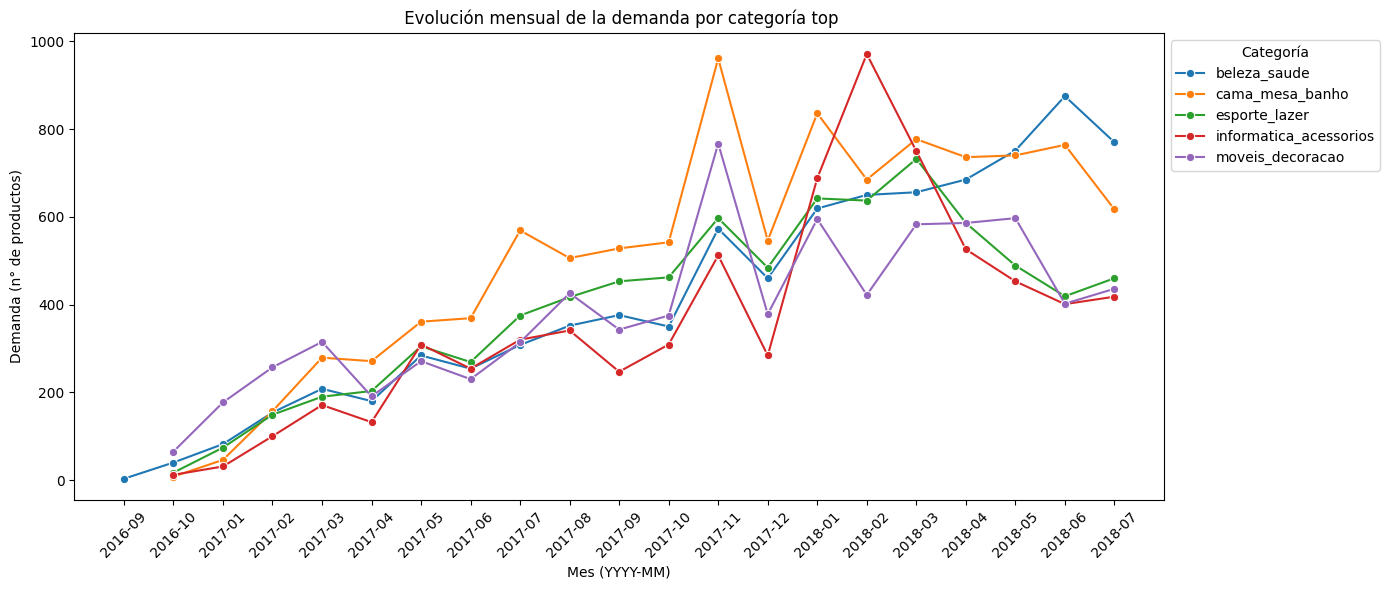

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# categorías con más ventas
top_cats = master.groupby('product_category_name')['demand'].sum().sort_values(ascending=False).head(5).index

# categorías más importantes
plot_df = master[master['product_category_name'].isin(top_cats)]

plt.figure(figsize=(14,6))
sns.lineplot(data=plot_df, x='order_month', y='demand', hue='product_category_name', marker='o')
plt.title(' Evolución mensual de la demanda por categoría top')
plt.xticks(rotation=45)
plt.ylabel('Demanda (n° de productos)')
plt.xlabel('Mes (YYYY-MM)')
plt.legend(title='Categoría', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()


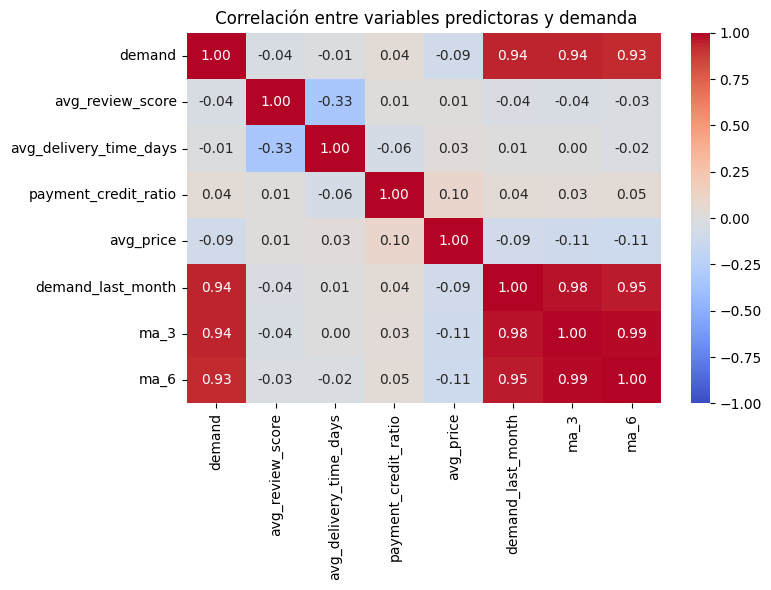

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = master[['demand', 'avg_review_score', 'avg_delivery_time_days',
               'payment_credit_ratio', 'avg_price', 'demand_last_month',
               'ma_3', 'ma_6']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title(" Correlación entre variables predictoras y demanda")
plt.tight_layout()
plt.show()


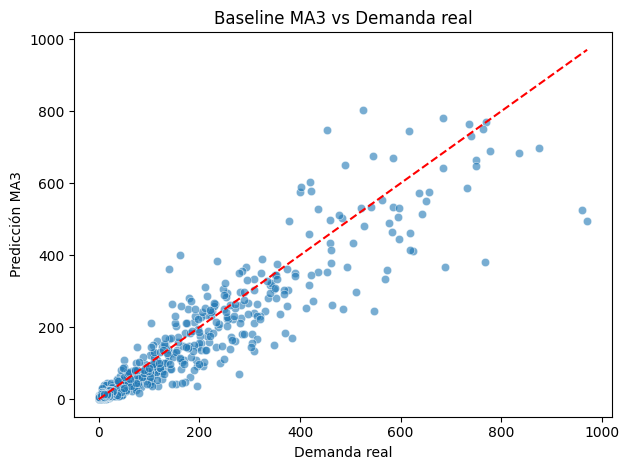

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

tmp = master.d-ropna(subset=['demand','ma_3']).copy()
sns.scatterplot(x=tmp['demand'], y=tmp['ma_3'], alpha=0.6)
plt.plot([0, max(tmp['demand'])], [0, max(tmp['demand'])], '--r')
plt.xlabel("Demanda real")
plt.ylabel("Predicción MA3")
plt.title("Baseline MA3 vs Demanda real")
plt.tight_layout()
plt.show()


/tmp/ipython-input-1130062016.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: mean_absolute_error(g['demand'], g['ma_3']))
/tmp/ipython-input-1130062016.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=err.sort_values('MAE', ascending=False).head(10),


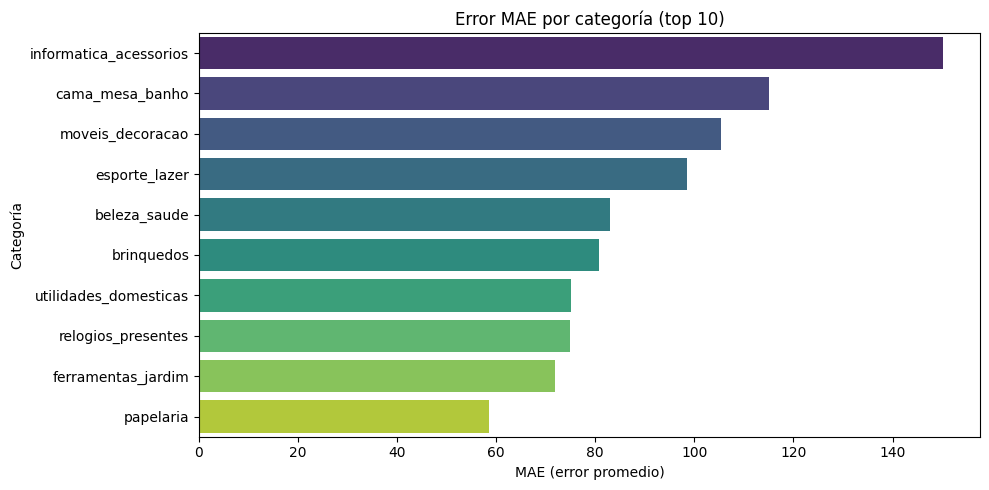

In [ ]:
from sklearn.metrics import mean_absolute_error

err = (master.dropna(subset=['ma_3'])
        .groupby('product_category_name')
        .apply(lambda g: mean_absolute_error(g['demand'], g['ma_3']))
        .reset_index(name='MAE'))

plt.figure(figsize=(10,5))
sns.barplot(data=err.sort_values('MAE', ascending=False).head(10),
            x='MAE', y='product_category_name', palette='viridis')
plt.title('Error MAE por categoría (top 10)')
plt.xlabel('MAE (error promedio)')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()


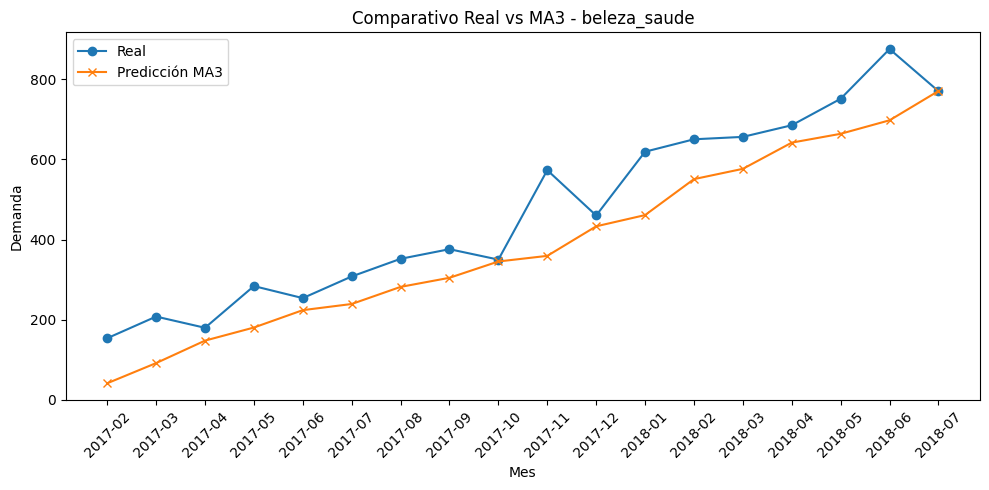

In [ ]:
cat = 'beleza_saude'
cat_df = master[master['product_category_name']==cat].dropna(subset=['ma_3'])
plt.figure(figsize=(10,5))
plt.plot(cat_df['order_month'], cat_df['demand'], label='Real', marker='o')
plt.plot(cat_df['order_month'], cat_df['ma_3'], label='Predicción MA3', marker='x')
plt.title(f"Comparativo Real vs MA3 - {cat}")
plt.xlabel("Mes")
plt.ylabel("Demanda")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
